# Crop Recommendation System — Model Training


In this notebook, we'll train machine learning models on the preprocessed dataset, compare their performance, and save the best model for future use.


In [4]:

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [5]:
# Step 2: Load Preprocessed Train Data
X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')
print("Data Loaded Successfully!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Data Loaded Successfully!
Train shape: (1760, 7)
Test shape: (440, 7)


In [3]:
#  Step 3: Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f" Decision Tree Accuracy: {acc_dt * 100:.2f}%")

 Decision Tree Accuracy: 97.95%


In [6]:
# Step 4: Train Random Forest Classifier
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train.values.ravel())
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")

Random Forest Accuracy: 99.55%


C:\Users\Dell\AppData\Local\Temp\ipykernel_14980\2499035235.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='Accuracy', palette='Greens')


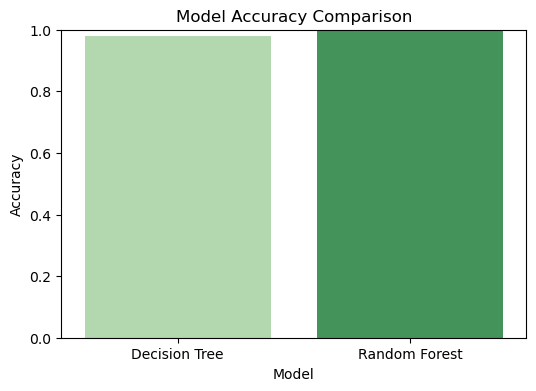


 Classification Report for Best Model (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00  

In [5]:

# Step 5: Compare Model Performance
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [acc_dt, acc_rf]
})

plt.figure(figsize=(6,4))
sns.barplot(data=results, x='Model', y='Accuracy', palette='Greens')
plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.show()

print("\n Classification Report for Best Model (Random Forest):")
print(classification_report(y_test, y_pred_rf))

In [6]:
# Step 6: Save the Best Model
best_model = rf if acc_rf >= acc_dt else dt
with open('../models/crop_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Best model saved successfully as crop_model.pkl!")

Best model saved successfully as crop_model.pkl!



### Summary
- Trained **Decision Tree** and **Random Forest** models  
- Compared accuracies visually  
- Saved the best-performing model (`crop_model.pkl`)  
- Ready for evaluation and tuning in the next step  